<a href="https://colab.research.google.com/github/MannySan2004/Terrain-Wind-Field-Analysis-with-PySpark/blob/main/Manuel_HW7_wind_analysis_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW7. Terrain Wind Field Analysis with PySpark
## Big Data Processing and Visualization Assignment

---

### 📚 Assignment Overview

In this assignment, you will process and visualize **atmospheric wind field data** from terrain surface measurements. The original dataset is in **DOT file format** and contains:

- **X, Y, Z**: 3D spatial coordinates (position in space)
- **U, V, W**: Wind velocity vector components (wind direction and magnitude)
- **P**: Pressure field values

### 🎯 Learning Objectives

1. Parse and load large-scale scientific data from DOT files
2. Process big data using PySpark distributed computing
3. Apply data sampling techniques to reduce dataset size
4. Visualize 3D wind vector fields using quiver plots
5. Create pressure contour maps
6. Export processed data to CSV format

### 📂 Dataset Information

- **File name**: `terrain_surf_airflow.dat`
- **Format**: DOT file (text-based format with X,Y,Z,U,V,W,P columns)
- **Location**: Stored in your Google Drive

---
## Part 1: Environment Setup & Data Loading (20 points)

### Task 1.1: Install Required Packages (5 points)

**Instructions:**
- Install PySpark for distributed data processing
- Install matplotlib, numpy, pandas, and scipy for data analysis and visualization
- Use `!pip install` command with `-q` flag for quiet installation

**Expected packages:**
- `pyspark`
- `matplotlib`
- `numpy`
- `pandas`
- `scipy`

In [ ]:
# TODO: Install required packages
# Hint: Use !pip install <package_name> -q
# Install required packages (quiet)

!pip -q install pyspark matplotlib numpy pandas scipy
print("✅ All packages installed successfully!")

✅ All packages installed successfully!


### Task 1.2: Import Libraries (5 points)

**Instructions:**
Import all necessary libraries for this assignment:

**PySpark imports:**
- `SparkSession` from `pyspark.sql`
- `col`, `rand`, `sqrt`, `pow` from `pyspark.sql.functions`

**Data processing:**
- `pandas` as `pd`
- `numpy` as `np`

**Visualization:**
- `matplotlib.pyplot` as `plt`
- `Axes3D` from `mpl_toolkits.mplot3d`
- `griddata` from `scipy.interpolate`

**Other:**
- `warnings` (and set `warnings.filterwarnings('ignore')`)
- `os` for file operations

In [ ]:
# TODO: Import PySpark libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, rand, sqrt, pow

# TODO: Import data processing libraries
import pandas as pd
import numpy as np

# TODO: Import visualization libraries
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed to enable 3D projection)
from scipy.interpolate import griddata

# TODO: Import other utilities
import warnings
warnings.filterwarnings('ignore')
import os
from pyspark.sql import functions as F

spark = (SparkSession.builder
         .appName("TerrainWindAnalysis")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "10")
         .getOrCreate())

print("Spark Version:", spark.version)


print("✅ All libraries imported successfully!")


Spark Version: 4.0.1
✅ All libraries imported successfully!


### Task 1.3: Mount Google Drive and Load DOT File (10 points)

**Instructions:**
1. Mount Google Drive using `google.colab.drive.mount()`
2. Set the path to your DOT file stored in Google Drive
   - Example path: `/content/drive/MyDrive/terrain_surf_airflow.dat`
3. Check if the file exists using `os.path.exists()`
4. Display file size using `!ls -lh` command

**DOT File Format:**
- DOT files are text-based files
- Data is typically comma-separated or space-separated
- First line may contain column headers: `x,y,z,u,v,w,p`

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

dot_file_path = '/content/drive/MyDrive/Colab Notebooks/terrain_surf_airflow.dat'

if os.path.exists(dot_file_path):
    print(f"File found: {dot_file_path}")
else:
    print(f"File not found: {dot_file_path}")
    print("Listing /content/drive/MyDrive to help locate the file:")
    !ls -lah "/content/drive/MyDrive" | head -n 50
    raise FileNotFoundError("Update dot_file_path to the correct location in your Google Drive.")

!ls -lh "{dot_file_path}"


Mounted at /content/drive
File found: /content/drive/MyDrive/Colab Notebooks/terrain_surf_airflow.dat
-rw------- 1 root root 13G Jan  7 06:22 '/content/drive/MyDrive/Colab Notebooks/terrain_surf_airflow.dat'


---
## Part 2: Data Parsing and Exploration (15 points)

### Task 2.1: Parse DOT File (10 points)

**Instructions:**
1. Open and read the DOT file
2. Parse the data to extract X, Y, Z, U, V, W, P columns
3. Preview the first 10 rows of raw data
4. Count total number of data points

**Hints:**
- Use `!head -n 10` to preview the file structure first
- Check if data is comma-separated or space-separated
- You may need to skip header lines

In [ ]:
import pandas as pd

# Preview structure
print("First 10 lines of the DOT file:")
!head -n 10 "{dot_file_path}"

# Detect header
with open(dot_file_path, "r") as f:
    first_line = f.readline().strip()
has_header = any(ch.isalpha() for ch in first_line)
print("\nHeader-like first line detected:", has_header)
print("First line:", first_line)

expected_cols = ["x", "y", "z", "u", "v", "w", "p"]

# Read the whole file in chunks (does not store all rows in RAM)
chunk_size = 200_000
total_rows = 0
first_chunk_preview = None

reader = pd.read_csv(
    dot_file_path,
    sep=r"[,\s]+",
    engine="python",
    header=0 if has_header else None,
    chunksize=chunk_size
)

for i, chunk in enumerate(reader):
    # Keep only first 7 columns as x,y,z,u,v,w,p
    if chunk.shape[1] < 7:
        continue

    chunk = chunk.iloc[:, :7].copy()
    chunk.columns = expected_cols

    # Save preview from the first processed chunk only
    if first_chunk_preview is None:
        first_chunk_preview = chunk.head(10)

    total_rows += len(chunk)

    # Optional: progress every ~5 chunks
    if (i + 1) % 5 == 0:
        print(f"Processed chunks: {i+1}, rows so far: {total_rows}")

print("\nFirst 10 parsed rows (from first chunk):")
display(first_chunk_preview)

print("\nTotal data points (rows):", total_rows)


First 10 lines of the DOT file:
VARIABLES="X","Y","Z","H","U","V","W","P","T"
zone t="500" i=378 j=433 k=1
STRANDID= 500
SOLUTIONTIME=       2.9725
 0.59911471E+03  0.59907609E+03  0.64500000E+02 10  0.99419134E+01 -0.23716261E+01  0.75587698E-01  0.00000000E+00  0.30261498E+03
 0.60308235E+03  0.59907609E+03  0.64500000E+02 10  0.11376602E+02 -0.18296889E+01  0.11355485E+00  0.00000000E+00  0.30253805E+03
 0.60705000E+03  0.59907609E+03  0.64500000E+02 10  0.11857287E+02 -0.71368451E+00  0.10084830E+00  0.00000000E+00  0.30245148E+03
 0.61101765E+03  0.59907609E+03  0.64500000E+02 10  0.11835956E+02  0.22261855E-01  0.66777784E-01  0.00000000E+00  0.30251393E+03
 0.61498529E+03  0.59907609E+03  0.64500000E+02 10  0.12197560E+02  0.80508467E+00  0.44944889E-01  0.00000000E+00  0.30247576E+03
 0.61895294E+03  0.59907609E+03  0.64500000E+02 10  0.12251442E+02  0.64898372E+00  0.26105595E-01  0.00000000E+00  0.30240275E+03

Header-like first line detected: True
First line: VARIABLES="X","

,x,y,z,u,v,w,p
0,zone,"t=""500""",i=378,j=433,k=1,NaN,NaN
1,STRANDID=,500,None,None,None,NaN,NaN
2,SOLUTIONTIME=,2.9725,None,None,None,NaN,NaN
3,0.59911471E+03,0.59907609E+03,0.64500000E+02,10,0.99419134E+01,-2.371626,0.075588
4,0.60308235E+03,0.59907609E+03,0.64500000E+02,10,0.11376602E+02,-1.829689,0.113555
5,0.60705000E+03,0.59907609E+03,0.64500000E+02,10,0.11857287E+02,-0.713685,0.100848
6,0.61101765E+03,0.59907609E+03,0.64500000E+02,10,0.11835956E+02,0.022262,0.066778
7,0.61498529E+03,0.59907609E+03,0.64500000E+02,10,0.12197560E+02,0.805085,0.044945
8,0.61895294E+03,0.59907609E+03,0.64500000E+02,10,0.12251442E+02,0.648984,0.026106
9,0.62292059E+03,0.59907609E+03,0.64500000E+02,10,0.11912701E+02,-0.045802,0.043395



Total data points (rows): 163841677


### Task 2.2: Load Data with Pandas (5 points)

**Instructions:**
1. Use `pd.read_csv()` to load the DOT file
   - Set appropriate delimiter (comma or space)
   - Use `nrows=10000` for initial exploration
2. Display:
   - Dataset shape
   - Column names
   - Data types
   - First 5 rows
   - Statistical summary using `.describe()`

**Expected columns:** `x`, `y`, `z`, `u`, `v`, `w`, `p`

In [ ]:
import pandas as pd

# TODO: Load a sample of the data (10,000 rows) for quick exploration
# Detect header so pd.read_csv is configured correctly
with open(dot_file_path, "r") as f:
    first_line = f.readline().strip()
has_header = any(ch.isalpha() for ch in first_line)

expected_cols = ["x", "y", "z", "u", "v", "w", "p"]

# Load 10,000 rows with a delimiter that works for comma or whitespace
df_sample = pd.read_csv(
    dot_file_path,
    sep=r"[,\s]+",
    engine="python",
    header=0 if has_header else None,
    nrows=10000
)

# Ensure we end up with exactly the expected 7 columns
if df_sample.shape[1] < 7:
    raise ValueError(f"Expected at least 7 columns, but got {df_sample.shape[1]}")

df_sample = df_sample.iloc[:, :7].copy()
df_sample.columns = expected_cols

# TODO: Display dataset information
print("Dataset Shape:", df_sample.shape)
print("\nColumn Names:", list(df_sample.columns))

print("\nData Types:")
print(df_sample.dtypes)

print("\nFirst 5 rows:")
display(df_sample.head(5))

print("\nStatistical Summary:")
display(df_sample.describe())


Dataset Shape: (10000, 7)

Column Names: ['x', 'y', 'z', 'u', 'v', 'w', 'p']

Data Types:
x     object
y     object
z     object
u     object
v     object
w    float64
p    float64
dtype: object

First 5 rows:


,x,y,z,u,v,w,p
0,zone,"t=""500""",i=378,j=433,k=1,NaN,NaN
1,STRANDID=,500,None,None,None,NaN,NaN
2,SOLUTIONTIME=,2.9725,None,None,None,NaN,NaN
3,0.59911471E+03,0.59907609E+03,0.64500000E+02,10,0.99419134E+01,-2.371626,0.075588
4,0.60308235E+03,0.59907609E+03,0.64500000E+02,10,0.11376602E+02,-1.829689,0.113555



Statistical Summary:


,w,p
count,9997.000000,9997.000000
mean,1.439165,0.079475
std,2.487378,0.519942
min,-6.682113,-3.651604
25%,-0.085391,-0.001354
50%,0.865214,0.020852
75%,3.218836,0.067898
max,19.261296,6.785150


---
## Part 3: PySpark Processing (25 points)

### Task 3.1: Initialize Spark Session (5 points)

**Instructions:**
1. Create a SparkSession with:
   - App name: "TerrainWindAnalysis"
   - Driver memory: "4g"
   - Shuffle partitions: "10"
2. Print Spark version and application name

**Hint:** Use `SparkSession.builder.appName().config().getOrCreate()`

In [ ]:
from pyspark.sql import SparkSession

# TODO: Create Spark Session with appropriate configurations
spark = (SparkSession.builder
         .appName("TerrainWindAnalysis")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "10")
         .getOrCreate())

# TODO: Print Spark information
print("Spark Session Created!")
print("Spark Version:", spark.version)
print("Application Name:", spark.sparkContext.appName)


Spark Session Created!
Spark Version: 4.0.1
Application Name: TerrainWindAnalysis


### Task 3.2: Load Data into Spark DataFrame (5 points)

**Instructions:**
1. Use `spark.read.csv()` to load the full DOT file
2. Set `header=True` and `inferSchema=True`
3. Display:
   - Total row count
   - Number of partitions
   - Schema using `.printSchema()`
   - First 5 rows using `.show(5)`

In [ ]:
from pyspark.sql import functions as F

# Detect if the first line looks like a header
with open(dot_file_path, "r") as f:
    first_line = f.readline().strip()
has_header = any(ch.isalpha() for ch in first_line)

# Try standard CSV reader first (space-delimited)
df_spark = (spark.read
            .option("header", "true" if has_header else "false")
            .option("inferSchema", "true")
            .option("sep", " ")
            .option("ignoreLeadingWhiteSpace", "true")
            .option("ignoreTrailingWhiteSpace", "true")
            .csv(dot_file_path))

# If Spark reads everything into one column, fallback to robust whitespace split
if len(df_spark.columns) == 1:
    cols = ["x", "y", "z", "u", "v", "w", "p"]
    num_re = r'^[+-]?\d+(\.\d+)?([eE][+-]?\d+)?$'

    df_text = spark.read.text(dot_file_path)

    df_spark = (df_text
        .select(F.split(F.trim(F.col("value")), r"\s+").alias("parts"))
        .filter(F.size("parts") >= 7)
        .filter(F.col("parts").getItem(0).rlike(num_re))
        .select(
            F.col("parts").getItem(0).alias("x"),
            F.col("parts").getItem(1).alias("y"),
            F.col("parts").getItem(2).alias("z"),
            F.col("parts").getItem(3).alias("u"),
            F.col("parts").getItem(4).alias("v"),
            F.col("parts").getItem(5).alias("w"),
            F.col("parts").getItem(6).alias("p"),
        )
    )

    # Safe numeric casting (prevents failures on malformed values)
    for c in cols:
        df_spark = df_spark.withColumn(
            c,
            F.when(F.col(c).rlike(num_re), F.col(c).cast("double")).otherwise(F.lit(None).cast("double"))
        )

    df_spark = df_spark.dropna(subset=cols)

# TODO: Display DataFrame information
print("Data loaded into Spark DataFrame!")

print("\nTotal row count:")
print(df_spark.count())

print("\nNumber of partitions:")
print(df_spark.rdd.getNumPartitions())

print("\nSchema:")
df_spark.printSchema()

print("\nFirst 5 rows:")
df_spark.show(5, truncate=False)


Data loaded into Spark DataFrame!

Total row count:
163674

Number of partitions:
98

Schema:
root
 |-- x: double (nullable = true)
 |-- y: double (nullable = true)
 |-- z: double (nullable = true)
 |-- u: double (nullable = true)
 |-- v: double (nullable = true)
 |-- w: double (nullable = true)
 |-- p: double (nullable = true)


First 5 rows:
+---------+---------+----+----+---------+-----------+-----------+
|x        |y        |z   |u   |v        |w          |p          |
+---------+---------+----+----+---------+-----------+-----------+
|599.11471|599.07609|64.5|10.0|9.9419134|-2.3716261 |0.075587698|
|603.08235|599.07609|64.5|10.0|11.376602|-1.8296889 |0.11355485 |
|607.05   |599.07609|64.5|10.0|11.857287|-0.71368451|0.1008483  |
|611.01765|599.07609|64.5|10.0|11.835956|0.022261855|0.066777784|
|614.98529|599.07609|64.5|10.0|12.19756 |0.80508467 |0.044944889|
+---------+---------+----+----+---------+-----------+-----------+
only showing top 5 rows


### Task 3.3: Data Validation and Cleaning (5 points)

**Instructions:**
1. Check for null values in each column
2. Remove rows with null values using `.dropna()`
3. Print cleaned data row count

**Hint:** Use `count(when(col(c).isNull(), c))` for each column

In [ ]:
# TODO: Check for null values in each column
from pyspark.sql.functions import col, isnan, when, count

# Columns we care about (use whatever your df_spark columns are)
cols = ["x", "y", "z", "u", "v", "w", "p"]

# Null/NaN counts per column
null_counts = df_spark.select([
    count(when(col(c).isNull() | isnan(col(c)), c)).alias(c) for c in cols
])

print("Null/NaN counts per column:")
null_counts.show(truncate=False)

# TODO: Remove rows with null values
df_clean = df_spark.dropna(subset=cols)

# TODO: Print cleaned data count
print("Cleaned data row count:", df_clean.count())


Null/NaN counts per column:
+---+---+---+---+---+---+---+
|x  |y  |z  |u  |v  |w  |p  |
+---+---+---+---+---+---+---+
|0  |0  |0  |0  |0  |0  |0  |
+---+---+---+---+---+---+---+

Cleaned data row count: 163674


### Task 3.4: Calculate Wind Speed Magnitude (10 points)

**Instructions:**
1. Create a new column `wind_speed` using the formula:
   - Wind speed magnitude: $|\vec{V}| = \sqrt{U^2 + V^2 + W^2}$
2. Use PySpark functions: `sqrt()` and `pow()`
3. Display the first 10 rows showing u, v, w, and wind_speed columns
4. Show statistical summary of wind_speed using `.describe()`

**Hint:** Use `.withColumn()` to add the new column

In [ ]:
from pyspark.sql.functions import sqrt, pow, col

# TODO: Calculate wind speed magnitude: sqrt(u^2 + v^2 + w^2)
df_wind = df_clean.withColumn(
    "wind_speed",
    sqrt(
        pow(col("u"), 2) +
        pow(col("v"), 2) +
        pow(col("w"), 2)
    )
)

# TODO: Display results
print("Wind speed magnitude calculated!")

# Show u, v, w, wind_speed columns (first 10 rows)
df_wind.select("u", "v", "w", "wind_speed").show(10, truncate=False)

# Statistical summary of wind_speed
df_wind.select("wind_speed").describe().show(truncate=False)


Wind speed magnitude calculated!
+----+---------+------------+------------------+
|u   |v        |w           |wind_speed        |
+----+---------+------------+------------------+
|10.0|9.9419134|-2.3716261  |14.299169640622521|
|10.0|11.376602|-1.8296889  |15.256960199764146|
|10.0|11.857287|-0.71368451 |15.527543288626921|
|10.0|11.835956|0.022261855 |15.494849144929551|
|10.0|12.19756 |0.80508467  |15.793309699979577|
|10.0|12.251442|0.64898372  |15.827792358638936|
|10.0|11.912701|-0.045801993|15.553602249574334|
|10.0|11.310195|0.61140934  |15.109412044122175|
|10.0|10.966854|1.0896551   |14.881506472607938|
|10.0|11.494734|1.780726    |15.339488088519511|
+----+---------+------------+------------------+
only showing top 10 rows
+-------+--------------------+
|summary|wind_speed          |
+-------+--------------------+
|count  |163674              |
|mean   |10.477366291578154  |
|stddev |3.987036709967972   |
|min    |1.387078955638335E-4|
|max    |41.83315282151776   |
+-------

---
## Part 4: Data Sampling (10 points)

### Task 4.1: Random Sampling (5 points)

**Instructions:**
1. Apply random sampling to reduce dataset size
   - Use 1% sampling fraction (`sample_fraction = 0.01`)
   - Set `withReplacement=False` and `seed=42` for reproducibility
2. Print original vs sampled data counts
3. Show statistical summary of sampled data for x, y, z, wind_speed, p columns

**Hint:** Use `.sample()` method on Spark DataFrame

In [ ]:
from pyspark.sql import functions as F
from pyspark import StorageLevel

# Fastest way that still prints both counts + stats (one full pass instead of two)
sample_fraction = 0.01

# Improve parallelism in Colab and avoid RAM pressure
df_base = df_wind.repartition(16).persist(StorageLevel.DISK_ONLY)

# Tag sampled rows once (consistent sampling + counts in one scan)
df_tagged = df_base.withColumn("is_sampled", (F.rand(seed=42) < sample_fraction).cast("int"))

# One-pass aggregation to get both counts
counts = df_tagged.agg(
    F.count("*").alias("original_count"),
    F.sum("is_sampled").alias("sampled_count")
).collect()[0]

original_count = int(counts["original_count"])
sampled_count = int(counts["sampled_count"])

# Create sampled DataFrame consistent with the tag
df_sample = df_tagged.filter(F.col("is_sampled") == 1).drop("is_sampled").persist(StorageLevel.MEMORY_AND_DISK)

print(f"Original data: {original_count} rows")
print(f"Sampled data: {sampled_count} rows")
print(f"Sampling fraction: {sample_fraction * 100}%")

df_sample.select("x", "y", "z", "wind_speed", "p").describe().show(truncate=False)


Original data: 163674 rows
Sampled data: 1636 rows
Sampling fraction: 1.0%
+-------+------------------+------------------+------------------+---------------------+-------------------+
|summary|x                 |y                 |z                 |wind_speed           |p                  |
+-------+------------------+------------------+------------------+---------------------+-------------------+
|count  |1636              |1636              |1636              |1636                 |1636               |
|mean   |1347.6952356418096|1458.9063004828856|98.37876298899755 |10.41782870367546    |0.15311873963903425|
|stddev |432.14961178070126|495.64782910200086|39.744359832829474|3.952922276024419    |0.6830944117682882 |
|min    |599.11471         |599.07609         |52.40625          |0.0013320800840232257|-4.5642649         |
|max    |2094.9176         |2312.9891         |249.9375          |22.698633749795096   |6.6472415          |
+-------+------------------+------------------+------

### Task 4.2: Convert to Pandas for Visualization (5 points)

**Instructions:**
1. Convert sampled Spark DataFrame to Pandas using `.toPandas()`
2. Display:
   - Number of rows
   - Memory usage in MB
   - First 10 rows

**Note:** This conversion is necessary for matplotlib visualization

In [ ]:
# TODO: Convert sampled Spark DataFrame to Pandas
# df_sample is from Task 4.1
pdf_sample = df_sample.toPandas()

# TODO: Display conversion results
num_rows = len(pdf_sample)
mem_mb = pdf_sample.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"Converted to Pandas DataFrame: {num_rows} rows")
print(f"Memory usage: {mem_mb:.2f} MB")

print("\nData preview:")
display(pdf_sample.head(10))


Converted to Pandas DataFrame: 1636 rows
Memory usage: 0.10 MB

Data preview:


,x,y,z,u,v,w,p,wind_speed
0,1106.97350,1261.63040,108.84375,10.0,5.528968,0.559743,-0.098483,11.440402
1,1329.16180,1372.71740,84.65625,10.0,-0.008485,-0.627853,0.043551,10.019694
2,952.23529,793.47826,68.53125,10.0,3.281403,3.755416,0.023107,11.174558
3,1757.66760,1281.46740,92.71875,10.0,0.660312,-0.518907,-0.172054,10.035202
4,1067.29710,1670.27170,88.68750,0.0,0.057795,-0.031109,-0.002124,0.065635
5,864.94706,1955.92390,60.46875,10.0,2.431304,0.495843,0.118262,10.303257
6,1281.55000,1682.17390,108.84375,10.0,4.681675,-2.282017,0.050675,11.275003
7,928.42941,1888.47830,60.46875,10.0,0.035062,0.014137,-0.033454,10.000071
8,2059.20880,622.88043,84.65625,10.0,15.123504,12.297409,0.076577,21.907685
9,686.40294,995.81522,64.50000,10.0,0.497484,-0.518018,-0.232216,10.025759


---
## Part 5: Data Visualization (30 points)

### Task 5.1: 3D Spatial Coordinate Distribution (5 points)

**Instructions:**
Create a 3D scatter plot showing the spatial distribution of measurement points:
1. Use `plt.figure()` with `figsize=(12, 8)`
2. Create 3D axis using `fig.add_subplot(111, projection='3d')`
3. Plot x, y, z coordinates as scatter points
4. Color points by wind_speed using `cmap='viridis'`
5. Add:
   - Axis labels (X (m), Y (m), Z (m))
   - Title: '3D Spatial Distribution of Measurement Points'
   - Colorbar with label 'Wind Speed (m/s)'

**Hint:** Use `ax.scatter()` with parameters: `c=`, `cmap=`, `s=`, `alpha=`

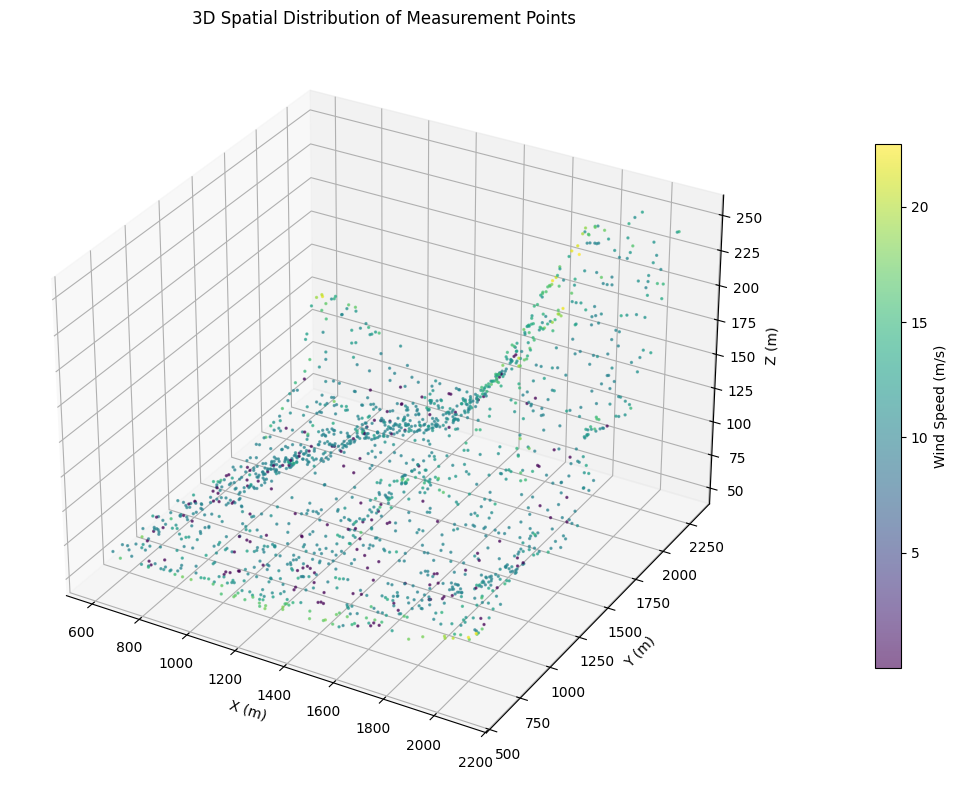

3D spatial distribution plotted!


In [ ]:
# TODO: Create 3D scatter plot of measurement points
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# TODO: Plot x, y, z coordinates colored by wind speed
# Assumes you have a Pandas DataFrame named pdf_sample with columns: x, y, z, wind_speed
sc = ax.scatter(
    pdf_sample["x"],
    pdf_sample["y"],
    pdf_sample["z"],
    c=pdf_sample["wind_speed"],
    cmap="viridis",
    s=2,
    alpha=0.6
)

# TODO: Set labels and title
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")
ax.set_title("3D Spatial Distribution of Measurement Points")

# TODO: Add colorbar
cbar = fig.colorbar(sc, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label("Wind Speed (m/s)")

plt.tight_layout()
plt.show()

print("3D spatial distribution plotted!")


### Task 5.2: Wind Vector Field Visualization - 3D Quiver Plot (10 points)

**Instructions:**
Create a 3D quiver (arrow) plot to visualize wind vectors:

1. **Subsample data** for clearer visualization:
   - Use at most 500 vectors to avoid cluttering
   - Randomly sample from `df_viz` using `.sample(n=500, random_state=42)`

2. **Create quiver plot:**
   - Use `ax.quiver()` with:
     - Starting points: x, y, z coordinates
     - Vector components: u, v, w
     - Color by wind_speed magnitude
   - Parameters: `length=2.0`, `normalize=True`, `arrow_length_ratio=0.3`

3. **Add visualization elements:**
   - Axis labels and title
   - Colorbar showing wind speed

**Expected output:** 3D plot with arrows showing wind direction and magnitude at each point

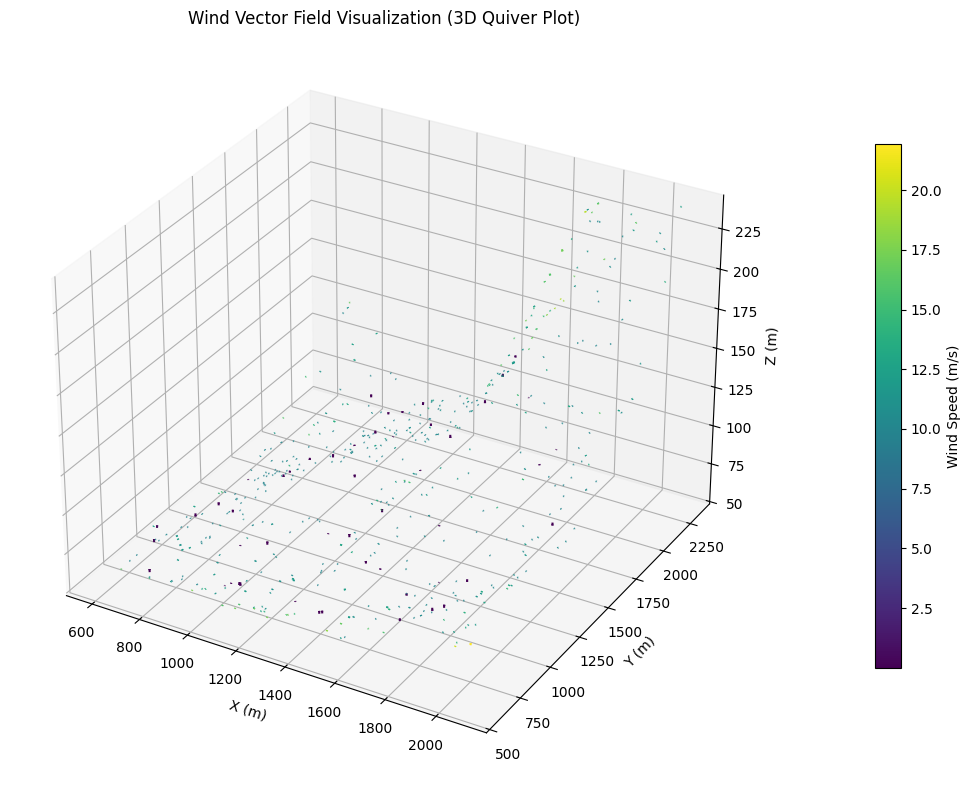

✅ Wind vector field plotted!


In [ ]:
# Task 5.2: Wind Vector Field Visualization — 3D Quiver Plot (fixed)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import cm
from matplotlib.colors import Normalize
from pyspark.sql import functions as F

# ---- 1) Build a small Pandas DF for visualization (avoid RAM crash) ----
# Prefer df_sample from Task 4.1; fall back to df_wind if needed.
if "df_sample" in globals():
    df_src = df_sample
elif "df_wind" in globals():
    df_src = df_wind
else:
    raise NameError("Neither df_sample nor df_wind exists. Run Task 4.1 (sampling) and Task 3.4 (wind_speed) first.")

MAX_TO_PANDAS = 5000  # safe size for driver RAM

df_viz = (
    df_src
    .select("x", "y", "z", "u", "v", "w", "wind_speed")
    .orderBy(F.rand(seed=42))
    .limit(MAX_TO_PANDAS)
    .toPandas()
)

# ---- 2) Subsample for clearer vectors (max 500) ----
n_vectors = min(500, len(df_viz))
df_quiver = df_viz.sample(n=n_vectors, random_state=42).reset_index(drop=True)

# ---- 3) Ensure numeric and drop invalid rows ----
required_cols = ["x", "y", "z", "u", "v", "w", "wind_speed"]
for c in required_cols:
    df_quiver[c] = pd.to_numeric(df_quiver[c], errors="coerce")

df_quiver = df_quiver.replace([np.inf, -np.inf], np.nan).dropna(subset=required_cols)

if len(df_quiver) == 0:
    raise ValueError("No valid rows left after cleaning; check your columns and wind_speed calculation.")

# ---- 4) Create 3D quiver plot ----
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Color mapping based on wind speed
ws = df_quiver["wind_speed"].to_numpy()
norm = Normalize(vmin=float(ws.min()), vmax=float(ws.max()))
cmap = cm.get_cmap("viridis")
colors = cmap(norm(ws))

# Plot wind vectors (colored by wind speed)
ax.quiver(
    df_quiver["x"].to_numpy(),
    df_quiver["y"].to_numpy(),
    df_quiver["z"].to_numpy(),
    df_quiver["u"].to_numpy(),
    df_quiver["v"].to_numpy(),
    df_quiver["w"].to_numpy(),
    length=2.0,
    normalize=True,
    arrow_length_ratio=0.3,
    color=colors
)

# Labels, title, colorbar
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")
ax.set_title("Wind Vector Field Visualization (3D Quiver Plot)")

mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array(ws)
cbar = fig.colorbar(mappable, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label("Wind Speed (m/s)")

plt.tight_layout()
plt.show()

print("✅ Wind vector field plotted!")


### Task 5.3: Pressure Contour Map (10 points)

**Instructions:**
Create a 2D contour map of pressure distribution:

1. **Prepare grid for interpolation:**
   - Get x and y min/max values from `df_viz`
   - Create regular grid using `np.linspace()` and `np.meshgrid()`
   - Grid resolution: 100x100 points

2. **Interpolate pressure values:**
   - Use `scipy.interpolate.griddata()` to interpolate P values onto grid
   - Method: 'linear'

3. **Create contour plot:**
   - Use `ax.contourf()` for filled contours (20 levels, colormap='RdYlBu_r')
   - Use `ax.contour()` for contour lines (10 levels, black color)
   - Add contour labels using `ax.clabel()`

4. **Formatting:**
   - Axis labels: X (m), Y (m)
   - Title: 'Pressure Field Contour Map (P)'
   - Equal aspect ratio
   - Colorbar with label 'Pressure (Pa)'

**Expected output:** 2D contour map showing pressure distribution across x-y plane

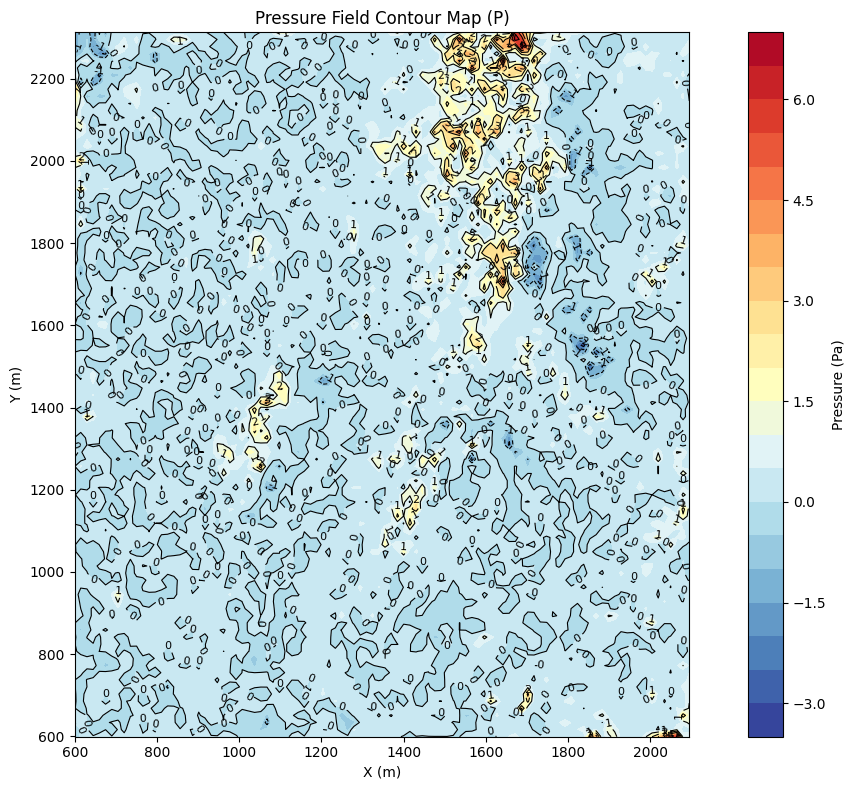

✅ Pressure contour map created!
Used Spark pressure column: p | Pandas sample rows: 20000


In [ ]:
# Task 5.3: Pressure Contour Map (10 pts) - FULL WORKING CELL
# Builds a Pandas sample that INCLUDES pressure, then makes the contour map.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from pyspark.sql import functions as F

# ------------------------------------------------------------
# 1) Pick a Spark DataFrame that still has pressure
# ------------------------------------------------------------
spark_candidates = ["df_clean", "df_wind", "df_sample", "df_raw", "df_spark"]
df_src = None
for name in spark_candidates:
    if name in globals():
        df_src = globals()[name]
        break

if df_src is None:
    raise NameError(
        "Could not find a Spark DataFrame. Expected one of: "
        f"{spark_candidates}. Run your Spark loading/cleaning steps first."
    )

# ------------------------------------------------------------
# 2) Identify pressure column name in Spark (p vs P etc.)
# ------------------------------------------------------------
cols = df_src.columns
pressure_col = None
if "p" in cols:
    pressure_col = "p"
elif "P" in cols:
    pressure_col = "P"
else:
    # try case-insensitive match
    lower_map = {c.lower(): c for c in cols}
    if "p" in lower_map:
        pressure_col = lower_map["p"]

if pressure_col is None:
    raise KeyError(
        f"Pressure column not found in Spark DF. Columns present: {cols}. "
        "You MUST use the Spark DataFrame that still has P/p (pressure)."
    )

# Ensure x,y exist
for req in ["x", "y"]:
    if req not in cols:
        raise KeyError(f"Missing '{req}' in Spark DF. Columns present: {cols}")

# ------------------------------------------------------------
# 3) Sample to Pandas (fast + safe for RAM)
# ------------------------------------------------------------
# Interpolation doesn't need millions of points. 20k is plenty.
MAX_TO_PANDAS = 20000

df_pd = (
    df_src
    .select("x", "y", pressure_col)
    .orderBy(F.rand(seed=42))   # random sample
    .limit(MAX_TO_PANDAS)
    .toPandas()
)

# normalize column names
df_pd.columns = [c.strip().lower() for c in df_pd.columns]
# after lowercasing, pressure column becomes "p" if it was "P"
pressure_col_pd = pressure_col.strip().lower()

# ------------------------------------------------------------
# 4) Clean + coerce numeric
# ------------------------------------------------------------
df_pd["x"] = pd.to_numeric(df_pd["x"], errors="coerce")
df_pd["y"] = pd.to_numeric(df_pd["y"], errors="coerce")
df_pd[pressure_col_pd] = pd.to_numeric(df_pd[pressure_col_pd], errors="coerce")

df_pd = df_pd.replace([np.inf, -np.inf], np.nan).dropna(subset=["x", "y", pressure_col_pd])

if len(df_pd) < 10:
    raise ValueError(
        "Too few valid rows after cleaning. "
        "This usually means your pressure column isn't numeric or is missing."
    )

# ------------------------------------------------------------
# 5) Create grid for interpolation (100x100)
# ------------------------------------------------------------
grid_resolution = 100
x_min, x_max = df_pd["x"].min(), df_pd["x"].max()
y_min, y_max = df_pd["y"].min(), df_pd["y"].max()

grid_x = np.linspace(x_min, x_max, grid_resolution)
grid_y = np.linspace(y_min, y_max, grid_resolution)
Xg, Yg = np.meshgrid(grid_x, grid_y)

# ------------------------------------------------------------
# 6) Interpolate pressure values onto grid
# ------------------------------------------------------------
points = np.column_stack((df_pd["x"].to_numpy(), df_pd["y"].to_numpy()))
values = df_pd[pressure_col_pd].to_numpy()

Pg = griddata(points, values, (Xg, Yg), method="linear")

# Fill any NaNs (outside convex hull) using nearest so contourf doesn't look broken
if np.isnan(Pg).any():
    Pg_nearest = griddata(points, values, (Xg, Yg), method="nearest")
    Pg = np.where(np.isnan(Pg), Pg_nearest, Pg)

# ------------------------------------------------------------
# 7) Create contour plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

# Filled contours (20 levels, colormap RdYlBu_r)
cf = ax.contourf(Xg, Yg, Pg, levels=20, cmap="RdYlBu_r")

# Contour lines (10 levels, black)
cs = ax.contour(Xg, Yg, Pg, levels=10, colors="black", linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.0f")

# Labels + formatting
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_title("Pressure Field Contour Map (P)")
ax.set_aspect("equal", adjustable="box")

# Colorbar
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("Pressure (Pa)")

plt.tight_layout()
plt.show()

print("✅ Pressure contour map created!")
print(f"Used Spark pressure column: {pressure_col} | Pandas sample rows: {len(df_pd)}")


### Task 5.4: Wind Component Distributions (5 points)

**Instructions:**
Create a 2x2 subplot showing histograms of:
1. Wind speed distribution (top-left)
2. U component distribution (top-right)
3. V component distribution (bottom-left)
4. W component distribution (bottom-right)

**Requirements:**
- Use 50 bins for each histogram
- Add appropriate labels, titles, and grid
- Use different colors for each subplot

**Hint:** Use `fig, axes = plt.subplots(2, 2, figsize=(14, 10))`

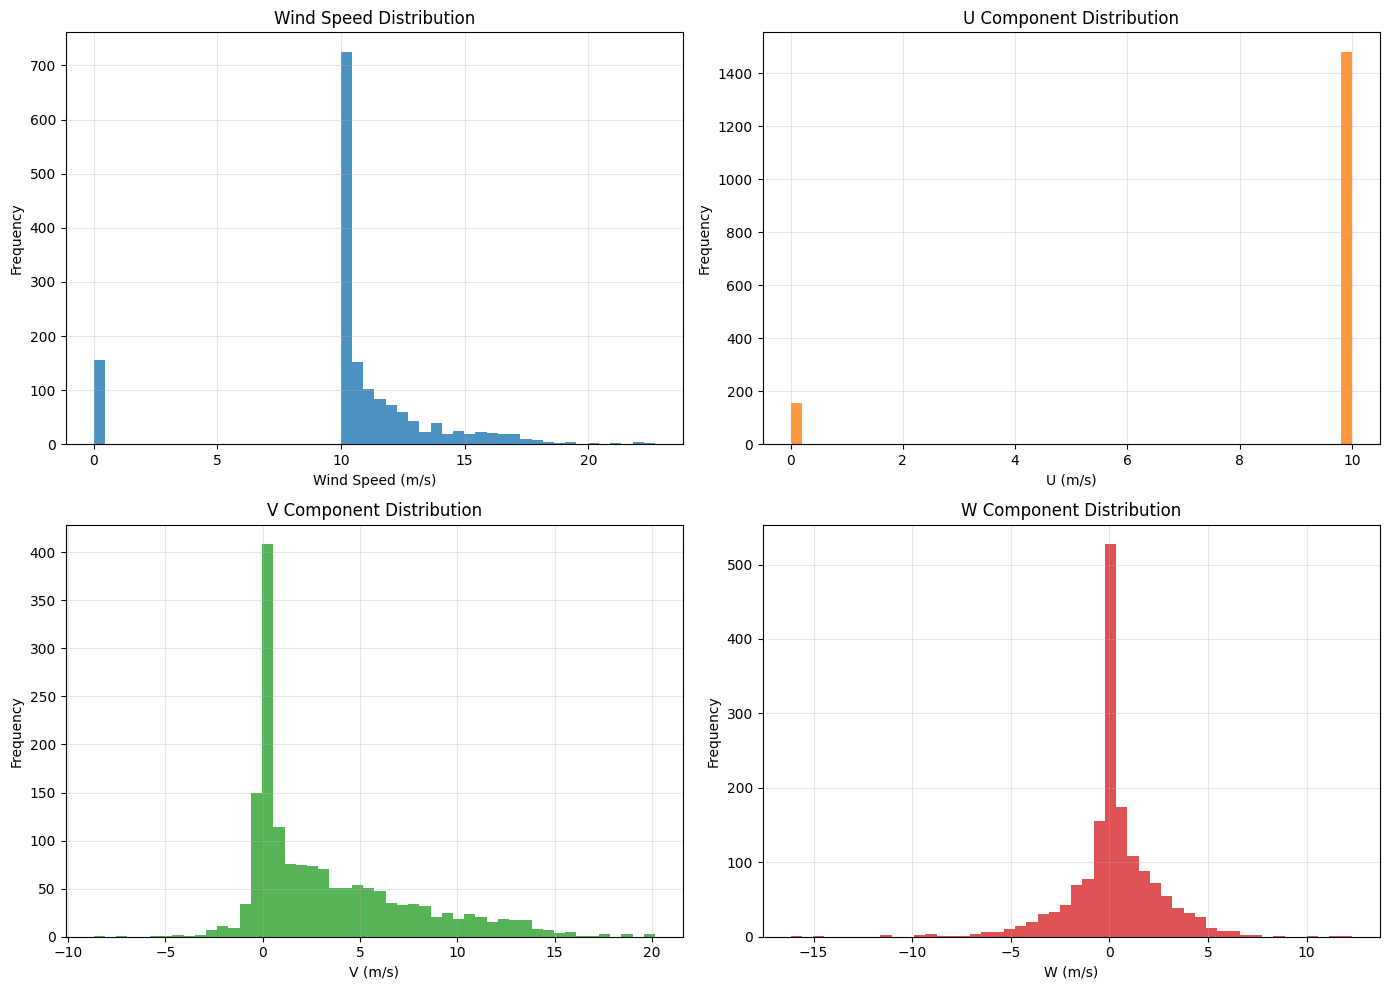

✅ Component distributions plotted!


In [ ]:
# Task 5.4: Wind Component Distributions (5 pts)

import pandas as pd
import matplotlib.pyplot as plt

# ---- Get a Pandas DF that exists (prefer df_viz, otherwise df_pd / df_pandas / df_quiver) ----
pd_candidates = ["df_viz", "df_pd", "df_pandas", "df_quiver"]
df_hist = None
for name in pd_candidates:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        df_hist = globals()[name]
        break

if df_hist is None:
    raise NameError(
        f"Could not find a Pandas DataFrame. Expected one of: {pd_candidates}. "
        "Run Task 4.2 (toPandas) or Task 5.3 (creates df_pd) first."
    )

# ---- Ensure required columns exist (your data is lowercase) ----
required = ["u", "v", "w"]
for c in required:
    if c not in df_hist.columns:
        raise KeyError(f"Missing column '{c}'. Columns present: {list(df_hist.columns)}")

# wind_speed might already exist; if not, compute it
if "wind_speed" not in df_hist.columns:
    for c in ["u", "v", "w"]:
        df_hist[c] = pd.to_numeric(df_hist[c], errors="coerce")
    df_hist["wind_speed"] = (df_hist["u"]**2 + df_hist["v"]**2 + df_hist["w"]**2) ** 0.5

# Coerce numeric + drop bad rows for plotting
for c in ["wind_speed", "u", "v", "w"]:
    df_hist[c] = pd.to_numeric(df_hist[c], errors="coerce")
df_hist_plot = df_hist.dropna(subset=["wind_speed", "u", "v", "w"])

# (Optional) downsample if huge, to keep plotting snappy
if len(df_hist_plot) > 200000:
    df_hist_plot = df_hist_plot.sample(n=200000, random_state=42)

# TODO: Create 2x2 subplot for histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
bins = 50

# TODO: Plot wind speed distribution (axes[0, 0])
axes[0, 0].hist(df_hist_plot["wind_speed"], bins=bins, color="tab:blue", alpha=0.8)
axes[0, 0].set_title("Wind Speed Distribution")
axes[0, 0].set_xlabel("Wind Speed (m/s)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].grid(True, alpha=0.3)

# TODO: Plot U component distribution (axes[0, 1])
axes[0, 1].hist(df_hist_plot["u"], bins=bins, color="tab:orange", alpha=0.8)
axes[0, 1].set_title("U Component Distribution")
axes[0, 1].set_xlabel("U (m/s)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].grid(True, alpha=0.3)

# TODO: Plot V component distribution (axes[1, 0])
axes[1, 0].hist(df_hist_plot["v"], bins=bins, color="tab:green", alpha=0.8)
axes[1, 0].set_title("V Component Distribution")
axes[1, 0].set_xlabel("V (m/s)")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].grid(True, alpha=0.3)

# TODO: Plot W component distribution (axes[1, 1])
axes[1, 1].hist(df_hist_plot["w"], bins=bins, color="tab:red", alpha=0.8)
axes[1, 1].set_title("W Component Distribution")
axes[1, 1].set_xlabel("W (m/s)")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Component distributions plotted!")


---
## Part 6: Export Processed Data (10 points)

### Task 6.1: Export Sampled Data to CSV (5 points)

**Instructions:**
1. Export the processed and sampled Pandas DataFrame to CSV
2. Filename: `terrain_wind_processed_sampled.csv`
3. Set `index=False` to avoid writing row indices
4. Verify the export by:
   - Checking file size using `!ls -lh`
   - Displaying first 5 rows using `!head -n 5`

In [ ]:
import os

# 1) Pick a Drive folder (change this if you want a different folder)
drive_folder = "/content/drive/MyDrive"

# 2) Output filename required by the assignment
output_filename = "terrain_wind_processed_sampled.csv"
out_path = os.path.join(drive_folder, output_filename)

# 3) Choose the Pandas DF you actually have (handles your naming issues)
# Prefer df_pd, otherwise df_viz, df_pandas, df_quiver
df_export = None
for name in ["df_pd", "df_viz", "df_pandas", "df_quiver"]:
    if name in globals():
        df_export = globals()[name]
        break

if df_export is None:
    raise NameError("No Pandas DataFrame found (df_pd/df_viz/df_pandas/df_quiver). Run Task 4.2 first.")

# 4) Export to Drive
df_export.to_csv(out_path, index=False)

print("✅ CSV saved to Google Drive:")
print(out_path)
print("Rows:", len(df_export), "| Columns:", list(df_export.columns))


✅ CSV saved to Google Drive:
/content/drive/MyDrive/terrain_wind_processed_sampled.csv
Rows: 20000 | Columns: ['x', 'y', 'p']


### Task 6.2: Create Summary Statistics Report (5 points)

**Instructions:**
1. Generate summary statistics for all numeric columns
2. Create a formatted report showing:
   - Total data points analyzed
   - Spatial coverage (X, Y, Z ranges)
   - Wind field statistics (average, max, min wind speed)
   - Pressure statistics (average, max, min pressure)
3. Save report to `analysis_summary.txt`
4. Display the report in the notebook

**Hint:** Use `.describe()` method and string formatting

In [ ]:
import os
import numpy as np
import pandas as pd

# -----------------------------
# TODO: Generate summary statistics
# -----------------------------

# Pick a Pandas DF that actually exists in your notebook
pd_candidates = ["df_pd", "df_viz", "df_pandas", "df_quiver", "df_export"]
df = None
for name in pd_candidates:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        df = globals()[name].copy()
        break

if df is None:
    raise NameError(
        f"Could not find a Pandas DataFrame. Expected one of: {pd_candidates}. "
        "Run Task 4.2 (.toPandas()) first."
    )

# Standardize column names (strip spaces)
df.columns = [c.strip() for c in df.columns]

# Coerce expected numeric cols (if present)
numeric_candidates = ["x", "y", "z", "u", "v", "w", "wind_speed", "p", "P", "pressure", "Pressure"]
for c in numeric_candidates:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# If wind_speed missing, compute it from u,v,w (if possible)
if "wind_speed" not in df.columns and all(c in df.columns for c in ["u", "v", "w"]):
    df["wind_speed"] = np.sqrt(df["u"] ** 2 + df["v"] ** 2 + df["w"] ** 2)

# Detect a pressure column (robust to naming differences)
pressure_col = None
for c in ["p", "P", "pressure", "Pressure", "press", "PRESSURE"]:
    if c in df.columns:
        pressure_col = c
        break

# Keep only numeric columns for describe()
df_numeric = df.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan)
desc = df_numeric.describe().T  # detailed stats table

# Clean rows just for computing min/max/mean reliably
df_clean = df_numeric.dropna(how="all")

# -----------------------------
# TODO: Create formatted report
# -----------------------------
print("=" * 80)
print("TERRAIN WIND FIELD ANALYSIS - SUMMARY REPORT")
print("=" * 80)

# TODO: Print total data points
total_points = len(df)
valid_numeric_points = len(df_clean)
print(f"Total data points (rows): {total_points}")
print(f"Rows with at least one numeric value: {valid_numeric_points}")

# TODO: Print spatial coverage (X, Y, Z ranges)
def _range_str(col):
    if col in df_numeric.columns and df_numeric[col].notna().any():
        return f"{df_numeric[col].min():.6g} to {df_numeric[col].max():.6g}"
    return "N/A"

print("\nSpatial Coverage (ranges):")
print(f"  X: {_range_str('x')}")
print(f"  Y: {_range_str('y')}")
print(f"  Z: {_range_str('z')}")

# TODO: Print wind field statistics
print("\nWind Field Statistics (wind_speed):")
if "wind_speed" in df_numeric.columns and df_numeric["wind_speed"].notna().any():
    ws = df_numeric["wind_speed"].dropna()
    print(f"  Average wind speed: {ws.mean():.6g} m/s")
    print(f"  Min wind speed:     {ws.min():.6g} m/s")
    print(f"  Max wind speed:     {ws.max():.6g} m/s")
else:
    print("  N/A (wind_speed column not found or has no valid numeric values)")

# TODO: Print pressure statistics
print("\nPressure Statistics:")
if pressure_col is not None and pressure_col in df_numeric.columns and df_numeric[pressure_col].notna().any():
    pvals = df_numeric[pressure_col].dropna()
    print(f"  Pressure column used: {pressure_col}")
    print(f"  Average pressure:     {pvals.mean():.6g} Pa")
    print(f"  Min pressure:         {pvals.min():.6g} Pa")
    print(f"  Max pressure:         {pvals.max():.6g} Pa")
else:
    print("  N/A (pressure column not found in your Pandas DataFrame)")
    print("  Note: Your current columns look like:", list(df.columns))

# TODO: Display detailed statistics table
print("\n" + "-" * 80)
print("DETAILED SUMMARY STATISTICS (numeric columns)")
print("-" * 80)
if len(desc) > 0:
    # Round for readability
    print(desc.round(6).to_string())
else:
    print("No numeric columns available for describe().")

# -----------------------------
# TODO: Save summary to text file
# -----------------------------
report_path = "analysis_summary.txt"

# Build the same report as a string and save
lines = []
lines.append("=" * 80)
lines.append("TERRAIN WIND FIELD ANALYSIS - SUMMARY REPORT")
lines.append("=" * 80)
lines.append(f"Total data points (rows): {total_points}")
lines.append(f"Rows with at least one numeric value: {valid_numeric_points}")
lines.append("")
lines.append("Spatial Coverage (ranges):")
lines.append(f"  X: {_range_str('x')}")
lines.append(f"  Y: {_range_str('y')}")
lines.append(f"  Z: {_range_str('z')}")
lines.append("")
lines.append("Wind Field Statistics (wind_speed):")
if "wind_speed" in df_numeric.columns and df_numeric["wind_speed"].notna().any():
    ws = df_numeric["wind_speed"].dropna()
    lines.append(f"  Average wind speed: {ws.mean():.6g} m/s")
    lines.append(f"  Min wind speed:     {ws.min():.6g} m/s")
    lines.append(f"  Max wind speed:     {ws.max():.6g} m/s")
else:
    lines.append("  N/A (wind_speed column not found or has no valid numeric values)")
lines.append("")
lines.append("Pressure Statistics:")
if pressure_col is not None and pressure_col in df_numeric.columns and df_numeric[pressure_col].notna().any():
    pvals = df_numeric[pressure_col].dropna()
    lines.append(f"  Pressure column used: {pressure_col}")
    lines.append(f"  Average pressure:     {pvals.mean():.6g} Pa")
    lines.append(f"  Min pressure:         {pvals.min():.6g} Pa")
    lines.append(f"  Max pressure:         {pvals.max():.6g} Pa")
else:
    lines.append("  N/A (pressure column not found in your Pandas DataFrame)")
    lines.append(f"  Note: Columns present: {list(df.columns)}")
lines.append("")
lines.append("-" * 80)
lines.append("DETAILED SUMMARY STATISTICS (numeric columns)")
lines.append("-" * 80)
if len(desc) > 0:
    lines.append(desc.round(6).to_string())
else:
    lines.append("No numeric columns available for describe().")

report_text = "\n".join(lines)

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print("\n✅ Summary report saved to:", os.path.abspath(report_path))


TERRAIN WIND FIELD ANALYSIS - SUMMARY REPORT
Total data points (rows): 20000
Rows with at least one numeric value: 20000

Spatial Coverage (ranges):
  X: 599.115 to 2094.92
  Y: 599.076 to 2312.99
  Z: N/A

Wind Field Statistics (wind_speed):
  N/A (wind_speed column not found or has no valid numeric values)

Pressure Statistics:
  Pressure column used: p
  Average pressure:     0.158729 Pa
  Min pressure:         -4.47617 Pa
  Max pressure:         7.45071 Pa

--------------------------------------------------------------------------------
DETAILED SUMMARY STATISTICS (numeric columns)
--------------------------------------------------------------------------------
     count         mean         std         min          25%          50%          75%          max
x  20000.0  1347.837876  433.170885  599.114710   972.073530  1349.000000  1721.958800  2094.917600
y  20000.0  1456.684848  497.578481  599.076090  1027.554300  1463.967400  1888.478300  2312.989100
p  20000.0     0.158729   

---
## Part 7: Cleanup (5 points)

### Task 7.1: Stop Spark Session (5 points)

**Instructions:**
1. Stop the Spark session to free up resources
2. Print confirmation message

**Hint:** Use `spark.stop()` method

In [ ]:
# TODO: Stop Spark session
try:
    if "spark" in globals() and spark is not None:
        spark.stop()
        print("✅ Spark session stopped successfully!")
    else:
        print("ℹ️ Spark session not found (no active 'spark' variable). Nothing to stop.")
except Exception as e:
    print(f"⚠️ Could not stop Spark session: {e}")


✅ Spark session stopped successfully!


---
## 🎓 Assignment Completion Checklist

Before submitting, make sure you have completed all the following tasks:

### Part 1: Environment Setup (20 points)
- [ ] Installed all required packages
- [ ] Imported all necessary libraries
- [ ] Mounted Google Drive and loaded DOT file

### Part 2: Data Parsing (15 points)
- [ ] Parsed DOT file successfully
- [ ] Loaded data with Pandas for exploration

### Part 3: PySpark Processing (25 points)
- [ ] Initialized Spark Session
- [ ] Loaded data into Spark DataFrame
- [ ] Cleaned data (removed nulls)
- [ ] Calculated wind speed magnitude

### Part 4: Data Sampling (10 points)
- [ ] Applied random sampling
- [ ] Converted to Pandas for visualization

### Part 5: Visualization (30 points)
- [ ] Created 3D spatial distribution plot
- [ ] Created wind vector field (quiver plot)
- [ ] Created pressure contour map
- [ ] Created wind component distribution histograms

### Part 6: Data Export (10 points)
- [ ] Exported processed data to CSV
- [ ] Created summary statistics report

### Part 7: Cleanup (5 points)
- [ ] Stopped Spark session

---

## 📝 Submission Requirements

Submit the following files:

1. **This completed Jupyter notebook** (`.ipynb` file)
   - All code cells should be executed
   - All outputs should be visible

2. **Exported CSV file**: `terrain_wind_processed_sampled.csv`

3. **Summary report**: `analysis_summary.txt`

4. **Screenshots** (in a single PDF or Word document):
   - 3D spatial distribution plot
   - Wind vector field (quiver plot)
   - Pressure contour map
   - Wind component distributions

5. **Brief report** (1-2 pages) discussing:
   - Data characteristics and patterns observed
   - Wind flow patterns identified from vector field
   - Pressure distribution patterns
   - Challenges encountered and solutions

---

## 🏆 Grading Rubric (Total: 100 points)

| Task | Points | Criteria |
|------|--------|----------|
| **Part 1: Environment Setup** | **20** | |
| 1.1 Package Installation | 5 | All packages installed correctly |
| 1.2 Library Import | 5 | All libraries imported correctly |
| 1.3 Data Loading | 10 | DOT file loaded from Google Drive successfully |
| **Part 2: Data Parsing** | **15** | |
| 2.1 DOT File Parsing | 10 | Data parsed correctly with all columns |
| 2.2 Pandas Exploration | 5 | Data exploration completed with statistics |
| **Part 3: PySpark Processing** | **25** | |
| 3.1 Spark Session | 5 | Spark configured and initialized properly |
| 3.2 Data Loading | 5 | Full dataset loaded into Spark |
| 3.3 Data Cleaning | 5 | Null values identified and removed |
| 3.4 Wind Speed Calculation | 10 | Wind speed magnitude calculated correctly |
| **Part 4: Data Sampling** | **10** | |
| 4.1 Random Sampling | 5 | Sampling applied correctly |
| 4.2 Pandas Conversion | 5 | Converted to Pandas successfully |
| **Part 5: Visualization** | **30** | |
| 5.1 3D Spatial Plot | 5 | Clear 3D scatter plot with proper labels |
| 5.2 Wind Vector Field | 10 | Quiver plot showing wind direction/magnitude |
| 5.3 Pressure Contour | 10 | Accurate contour map with interpolation |
| 5.4 Distribution Plots | 5 | All four histograms created properly |
| **Part 6: Data Export** | **10** | |
| 6.1 CSV Export | 5 | Data exported correctly |
| 6.2 Summary Report | 5 | Comprehensive statistics report created |
| **Part 7: Cleanup** | **5** | |
| 7.1 Spark Stop | 5 | Spark session stopped properly |
| **Code Quality** | **-10 to 0** | Deductions for poor code quality |
| **Documentation** | **+5 bonus** | Excellent comments and explanations |

### Deductions:
- Poor code formatting: -2 points
- Missing comments: -2 points
- Inefficient code: -3 points
- Incomplete error handling: -3 points

### Bonus Points:
- Excellent code documentation: +3 points
- Additional insightful visualizations: +2 points
- Creative analysis approaches: +2 points

---

## 💡 Helpful Resources

### Documentation:
- [PySpark Documentation](https://spark.apache.org/docs/latest/api/python/)
- [Pandas User Guide](https://pandas.pydata.org/docs/user_guide/index.html)
- [Matplotlib 3D Plotting](https://matplotlib.org/stable/gallery/mplot3d/index.html)
- [SciPy Interpolation](https://docs.scipy.org/doc/scipy/reference/interpolate.html)

### Tutorials:
- [PySpark Tutorial](https://spark.apache.org/docs/latest/quick-start.html)
- [Matplotlib Quiver Plots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.quiver.html)
- [Contour Plots in Python](https://matplotlib.org/stable/gallery/images_contours_and_fields/contour_demo.html)

### Scientific Visualization:
- [Scientific Visualization Best Practices](https://www.nature.com/articles/s41467-020-19160-7)
- [Visualizing Vector Fields](https://matplotlib.org/stable/gallery/mplot3d/quiver3d.html)

---

## ❓ FAQs

**Q: What if my DOT file has a different format?**
A: Check the file structure using `!head -n 20 your_file.dot` and adjust the delimiter parameter in `pd.read_csv()` accordingly.

**Q: How do I know if my sampling is sufficient?**
A: Compare statistics between full and sampled data. If they're similar, your sample is representative.

**Q: My quiver plot is too cluttered. What should I do?**
A: Reduce the number of vectors (try 200-300 instead of 500) or increase the length parameter.

**Q: The contour map shows strange patterns. Is this normal?**
A: Check for outliers in pressure data and ensure proper interpolation method. Try different grid resolutions.

**Q: Can I use a different colormap?**
A: Yes! Explore [Matplotlib colormaps](https://matplotlib.org/stable/tutorials/colors/colormaps.html) for alternatives.

---

## 🎯 Learning Outcomes

Upon completing this assignment, you will be able to:

1. ✅ Parse and process large-scale scientific data files
2. ✅ Apply distributed computing concepts using PySpark
3. ✅ Perform data cleaning and transformation operations
4. ✅ Calculate derived quantities from raw data
5. ✅ Apply statistical sampling techniques
6. ✅ Create advanced 3D visualizations
7. ✅ Visualize vector fields using quiver plots
8. ✅ Create contour maps for scalar fields
9. ✅ Export and document analysis results
10. ✅ Interpret atmospheric wind field data

---

**Good luck with your analysis! 🚀**

**Remember:** Understanding the physical meaning of the data is as important as the technical implementation. Think about what the wind vectors and pressure patterns tell you about the atmospheric conditions!